# **Supply Chain Route Optimization menggunakan OR TOOLS Google dan Simulated Annealing**

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import radians, sin, cos, sqrt, atan2
from sklearn.preprocessing import MinMaxScaler
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [70]:
df = pd.read_csv("supply_chain_logistic.csv", sep=';')

numeric_cols = [
    'penggunaan_bbm',
    'tingkat_kemacetan',
    'risiko_pengiriman']

# cleaning latitude
df['latitude'] = (
    df['latitude']
    .astype(str)
    .str.replace('.', '', regex=False))

df['latitude'] = pd.to_numeric(
    df['latitude'],
    errors='coerce') / 1e15

# cleaning longitude
df['longitude'] = (
    df['longitude']
    .astype(str)
    .str.replace('.', '', regex=False))

df['longitude'] = pd.to_numeric(
    df['longitude'],
    errors='coerce') / 1e15

# cleaning numeric features
for col in numeric_cols:
    df[col] = (df[col].astype(str).str.replace('.', '', regex=False))

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce')

# ambil sample
df = (df.sample(n=15, random_state=42).reset_index(drop=True))

# normalisasi
scaler = MinMaxScaler()

# buat beberapa node punya kondisi ekstrem
df.loc[10, 'tingkat_kemacetan'] = 1.0
df.loc[11, 'risiko_pengiriman'] = 1.0
df.loc[13, 'penggunaan_bbm'] = 1.0

df[numeric_cols] = scaler.fit_transform(
    df[numeric_cols])
print(df.head())

    latitude  longitude  penggunaan_bbm  tingkat_kemacetan  risiko_pengiriman
0   4.750485  -7.484776        0.285893           0.006911           0.153693
1  31.533646  -7.324354        0.199058           1.000000           0.161233
2  30.002357  -7.046873        0.092794           0.358311           1.000000
3   4.999279 -11.518510        0.186263           0.124954           0.164633
4  30.002796  -0.816313        0.197136           0.069013           0.368870


In [71]:
weights = {
    'distance': 0.45,
    'bbm': 0.30,
    'macet': 0.15,
    'risiko': 0.10}

## **Haversine Distance**

In [72]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2) ** 2 +
        cos(radians(lat1)) *
        cos(radians(lat2)) *
        sin(dlon / 2) ** 2)

    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

## **Cost Matrix**

In [ ]:
n = len(df)

distance_matrix = np.zeros((n, n))

# hitung jarak
for i in range(n):
    for j in range(n):
        if i != j:

            distance_matrix[i][j] = haversine(
                df.loc[i, 'latitude'],
                df.loc[i, 'longitude'],
                df.loc[j, 'latitude'],
                df.loc[j, 'longitude'])

# cost matrix
cost_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            distance = distance_matrix[i][j]
            penalty = (
                100 * df.loc[j, 'penggunaan_bbm'] +
                100 * df.loc[j, 'tingkat_kemacetan'] +
                100 * df.loc[j, 'risiko_pengiriman'])
            cost_matrix[i][j] = distance + penalty

## **OR Tools Optimization**

In [75]:
def solve_route(cost_matrix):

    manager = pywrapcp.RoutingIndexManager(len(cost_matrix),1,0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):

        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)

        return int(cost_matrix[from_node][to_node])

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)

    solution = routing.SolveWithParameters(search_parameters)
    route = []
    index = routing.Start(0)

    while not routing.IsEnd(index):
        route.append(manager.IndexToNode(index))
        index = solution.Value(
            routing.NextVar(index))
    route.append(0)

    return route

## **Rute Perbandingan**

In [76]:
# shortest distance only
distance_route = solve_route(distance_matrix)

# optimized multi-criteria
optimized_route = solve_route(cost_matrix)

print("Route Distance:")
print(distance_route)

print("\nRoute Optimized:")
print(optimized_route)

Route Distance:
[0, 8, 10, 13, 3, 12, 6, 5, 2, 1, 14, 4, 9, 11, 7, 0]

Route Optimized:
[0, 8, 10, 13, 3, 12, 6, 5, 2, 1, 14, 4, 9, 11, 7, 0]


## **Evaluasi**

In [77]:
def calculate_total(route):

    total_distance = 0
    total_bbm = 0
    total_macet = 0
    total_risiko = 0

    for i in range(len(route) - 1):

        from_node = route[i]
        to_node = route[i + 1]

        total_distance += distance_matrix[from_node][to_node]

        total_bbm += df.loc[to_node, 'penggunaan_bbm']

        total_macet += df.loc[to_node, 'tingkat_kemacetan']

        total_risiko += df.loc[to_node, 'risiko_pengiriman']

    return (
        total_distance,
        total_bbm,
        total_macet,
        total_risiko
    )

# shortest distance result
dist_d, bbm_d, macet_d, risiko_d = calculate_total(
    distance_route
)

# optimized result
dist_o, bbm_o, macet_o, risiko_o = calculate_total(
    optimized_route
)

print("===== SHORTEST DISTANCE =====")

print(f"Total Jarak (km) : {dist_d:.2f}")
print(f"Total BBM        : {bbm_d:.2f}")
print(f"Total Kemacetan  : {macet_d:.2f}")
print(f"Total Risiko     : {risiko_d:.2f}")

print("\n===== OPTIMIZED ROUTE =====")

print(f"Total Jarak (km) : {dist_o:.2f}")
print(f"Total BBM        : {bbm_o:.2f}")
print(f"Total Kemacetan  : {macet_o:.2f}")
print(f"Total Risiko     : {risiko_o:.2f}")

===== SHORTEST DISTANCE =====
Total Jarak (km) : 11055.41
Total BBM        : 3.02
Total Kemacetan  : 3.05
Total Risiko     : 3.73

===== OPTIMIZED ROUTE =====
Total Jarak (km) : 11055.41
Total BBM        : 3.02
Total Kemacetan  : 3.05
Total Risiko     : 3.73


## **Visualisasi**

In [78]:
def plot_route(route, title):
    plt.figure(figsize=(10, 7))
    plt.scatter(
        df['longitude'],
        df['latitude'])

    for i in range(len(route) - 1):
        x1 = df.loc[route[i], 'longitude']
        y1 = df.loc[route[i], 'latitude']

        x2 = df.loc[route[i + 1], 'longitude']
        y2 = df.loc[route[i + 1], 'latitude']

        plt.plot([x1, x2], [y1, y2])
        plt.text(
            x1,
            y1,
            str(i),
            fontsize=10)

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

## **Display Route**

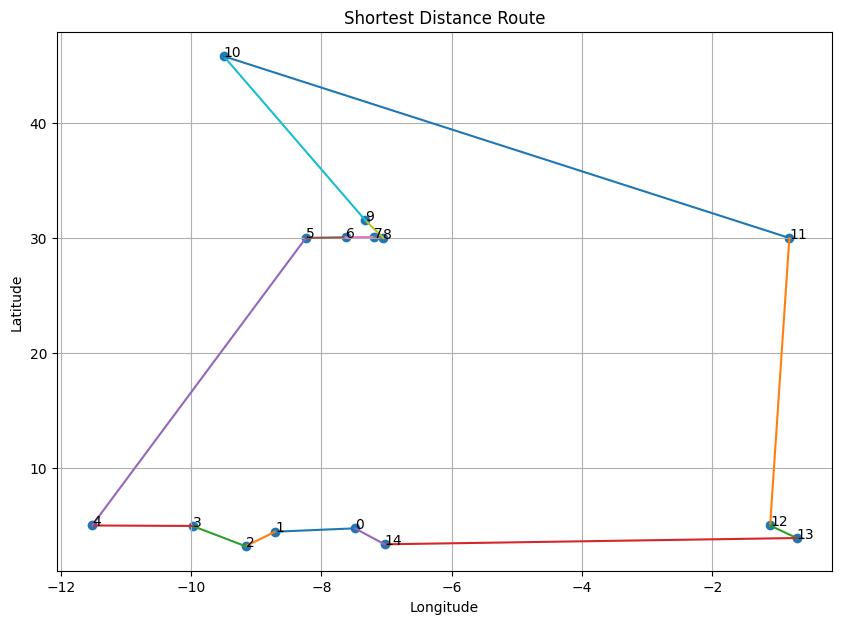

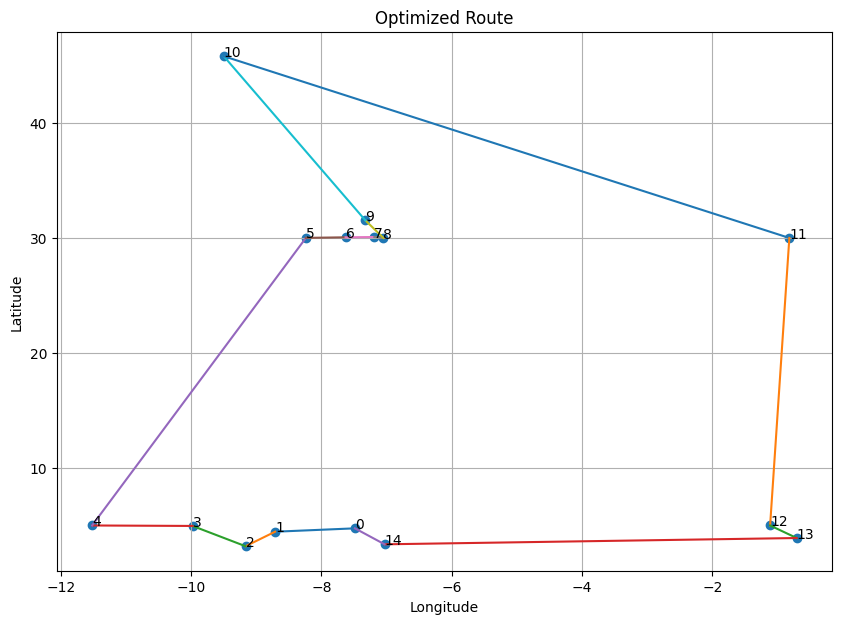

In [79]:
plot_route(distance_route,"Shortest Distance Route")

plot_route(optimized_route,"Optimized Route")

In [81]:
import pandas as pd
import joblib

from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(
    "supply_chain_logistic.csv",
    sep=';'
)

numeric_cols = [
    'penggunaan_bbm',
    'tingkat_kemacetan',
    'risiko_pengiriman'
]

for col in numeric_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

scaler = MinMaxScaler()

scaler.fit(df[numeric_cols])

joblib.dump(
    scaler,
    'scaler.pkl'
)

print("Scaler saved")

Scaler saved
